In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импортирую датасеты.

In [2]:
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_category_name = pd.read_csv('product_category_name_translation.csv')

Размерности датасетов.

In [3]:
df_names = ['df_customers', 'df_geolocation', 'df_items', 'df_payments', 'df_reviews', 'df_orders',
           'df_products', 'df_sellers', 'df_category_name']
for df in df_names:
    print(f'Датасет {df} имеет размерность: {eval(df).shape}')

Датасет df_customers имеет размерность: (99441, 5)
Датасет df_geolocation имеет размерность: (1000163, 5)
Датасет df_items имеет размерность: (112650, 7)
Датасет df_payments имеет размерность: (103886, 5)
Датасет df_reviews имеет размерность: (99224, 7)
Датасет df_orders имеет размерность: (99441, 8)
Датасет df_products имеет размерность: (32951, 9)
Датасет df_sellers имеет размерность: (3095, 4)
Датасет df_category_name имеет размерность: (71, 2)


# Анализ содержания датасетов.

In [4]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [6]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [9]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [12]:
df_category_name.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Исследуем датасеты на предмет пропущенных значений с дальнейшим заполнением пропусков.

In [13]:
df_customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [14]:
df_geolocation.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [15]:
df_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [16]:
df_payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [17]:
df_reviews.isna().sum() #Пропуски в представленных атрибутах это отсутствие заголовков/содержания комментариев
#соответственно сверху вниз, следовательно нет смысла заполнять эти пропуски, можно использовать имеющиеся значения
#для анализа тональностей

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [18]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [19]:
df_orders['order_approved_at'] = df_orders['order_approved_at'].fillna(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_carrier_date'] = df_orders['order_delivered_carrier_date'].fillna(df_orders['order_approved_at'])
df_orders['order_delivered_customer_date'] = df_orders['order_delivered_customer_date']\
    .fillna(df_orders['order_estimated_delivery_date'])

In [20]:
df_products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [21]:
df_products[df_products['product_width_cm'].isna()] #можно удалить эти строки, они не повлияют на дальнейший анализ

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_products = df_products[~df_products['product_width_cm'].isna()]

In [23]:
df_products[df_products['product_name_lenght'].isna()].head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0


Только размера мало, нам нужны данные о том, что это за товар для полезных выводов. Отбросим эти данные.

In [24]:
df_products = df_products[~df_products['product_name_lenght'].isna()]

In [25]:
df_sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [26]:
df_category_name.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

Теперь соберем датасет из всех нужных для анализа атрибутов других датасетов

In [27]:
df_reviews = df_reviews.drop(['review_comment_title'], axis=1) #Заголовки необязательны,
#анализ тональностей проводят на комментариях
df_reviews['review_comment_message'] = df_reviews['review_comment_message'].fillna('None')

In [28]:
df = pd.merge(df_orders, df_reviews, on='order_id')
df = pd.merge(df, df_payments, on='order_id')
df = pd.merge(df, df_items, on='order_id')
df = pd.merge(df, df_customers, on='customer_id')
df = pd.merge(df, df_products, on='product_id')
df = pd.merge(df, df_sellers, on='seller_id')
#df = pd.merge(df, df_geolocation, on='zip_code_prefix')

In [29]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP


In [30]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state'],
      dtype='object')

In [31]:
df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_id                        0
review_score                     0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name            0
product_name_lenght 

### Проведено изучение содержания датасетов, предобработка пропущенных значений, формирование единого датасета.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115633 entries, 0 to 115632
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       115633 non-null  object 
 1   customer_id                    115633 non-null  object 
 2   order_status                   115633 non-null  object 
 3   order_purchase_timestamp       115633 non-null  object 
 4   order_approved_at              115633 non-null  object 
 5   order_delivered_carrier_date   115633 non-null  object 
 6   order_delivered_customer_date  115633 non-null  object 
 7   order_estimated_delivery_date  115633 non-null  object 
 8   review_id                      115633 non-null  object 
 9   review_score                   115633 non-null  int64  
 10  review_comment_message         115633 non-null  object 
 11  review_creation_date           115633 non-null  object 
 12  review_answer_timestamp       

In [33]:
timestamp_atributes = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                      'order_delivered_customer_date', 'order_estimated_delivery_date']

Сменю тип данных с object на timestamp, посчитаю разницу во времени между предположительным временем доставки и фактическим.

In [34]:
for col in timestamp_atributes:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S')

---

## Анализ оценок

In [35]:
min_date, max_date = min(df['order_purchase_timestamp'].dt.date), max(df['order_purchase_timestamp'].dt.date)

In [36]:
print(max_date - min_date) #

729 days, 0:00:00


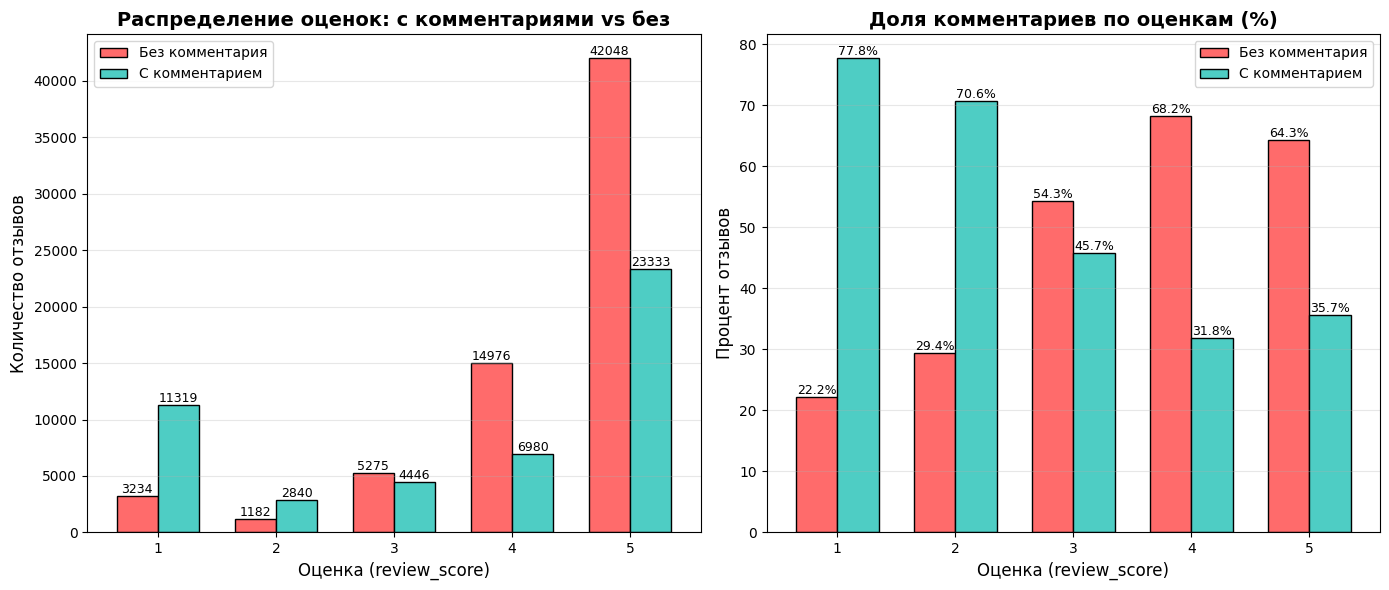

In [37]:
df['has_comment'] = df['review_comment_message'] != 'None'

# Считаем распределение
comment_dist = df.groupby(['review_score', 'has_comment']).size().unstack()

# Проценты по каждой оценке
comment_dist_pct = comment_dist.div(comment_dist.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Абсолютные значения
comment_dist.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', width=0.7)
ax1.set_title('Распределение оценок: с комментариями vs без', fontsize=14, fontweight='bold')
ax1.set_xlabel('Оценка (review_score)', fontsize=12)
ax1.set_ylabel('Количество отзывов', fontsize=12)
ax1.legend(['Без комментария', 'С комментарием'])
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Добавляем значения на столбцы
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=9)

# График 2: Проценты
comment_dist_pct.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', width=0.7)
ax2.set_title('Доля комментариев по оценкам (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Оценка (review_score)', fontsize=12)
ax2.set_ylabel('Процент отзывов', fontsize=12)
ax2.legend(['Без комментария', 'С комментарием'])
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

In [38]:
print(f'{df['has_comment'].sum()/len(df)*100:.1f}% заказов с комментариями')

42.3% заказов с комментариями


## Вывод
За период с 04.09.2016 по 03.09.2018
Всего 42.3% заказов сопровождаются комментариями. Из общего числа:
- негативные оценки (1-2) сопровождаются комментариями в ~74.2% случаев, следует провести анализ тональностей, выявить топ-3 причин негодования и приоритезировать их устранение.
- Нейтральные оценки (3) 45.7% от всех случаев сопровождаются комментариями, следует провести анализ тональностей для улучшения качества обслуживания и учесть рекомендации пользователей.
- Позитивные оценки (4-5) ~33.75% от всех случаев, довольные пользователи реже пишут комментарии, следует обратить внимание на имеющиеся, собрать фидбек и проанализировать что в сервисе уже хорошо работает.
> На 87к положительных отзывов 18к отрицательных
---

## Далее рассмотрим как коррелируют между собой своевременность доставки и отзывы

In [39]:
# Создаем условие: статус delivered И доставка с опозданием
condition = (df['order_status'] == 'delivered') & (df['order_delivered_customer_date'] > df['order_estimated_delivery_date'])

# Меняем значение
df.loc[condition, 'order_status'] = 'delivered_late'

будет удобно сделать гистограмму каждой оценки, где опоздала доставка, а где нет

In [40]:
delivered_df = df[df['order_status'].isin(['delivered', 'delivered_late'])].copy()

In [70]:
data = delivered_df.groupby(['review_score', 'order_status']).size().unstack()

In [71]:
data

order_status,delivered,delivered_late
review_score,,
1,8787,4080
2,3164,678
3,8569,967
4,20751,1070
5,63246,1920


<Figure size 1200x800 with 0 Axes>

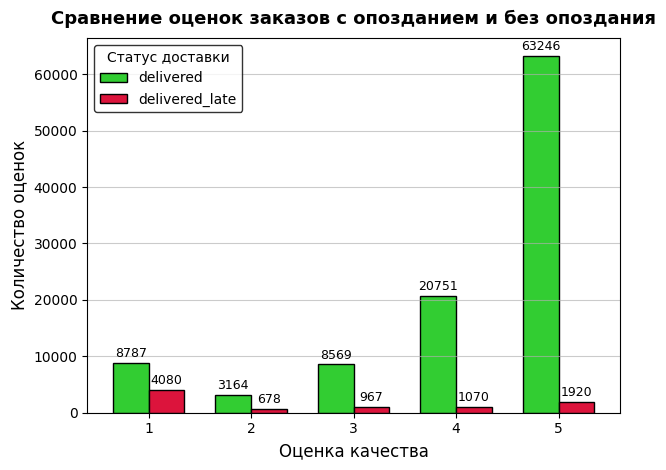

In [43]:
plt.figure(figsize=(12, 8))
data.plot(kind='bar', color=['#32CD32', '#DC143C'], edgecolor='black', width=.7)

plt.legend(title='Статус доставки', edgecolor='black')
plt.xlabel('Оценка качества', fontsize=12)
plt.ylabel('Количество оценок', fontsize=12)
plt.title('Сравнение оценок заказов с опозданием и без опоздания', fontsize=13, fontweight='bold', pad=10)

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.grid(axis='y', alpha=.65)
plt.xticks(rotation=0)
plt.tight_layout()

Нулевая гипотеза: Своевременность доставки не влияет на оценку покупателя (распределение оценок одинаково для delivered и delivered_late)

Альтернативная гипотеза: Своевременность доставки влияет на оценку (распределения различаются)

Проверим есть ли взаимосвязь статистически, если есть - насколько она сильная?

In [44]:
from scipy.stats import chi2_contingency

In [45]:
print("Таблица сопряженности:")
print(data)
print()

# Chi-square тест
chi2, p_value, dof, expected = chi2_contingency(data)

print(f"Результаты хи-квадрат теста:")
print(f"Хи-квадрат статистика: {chi2:.2f}")
print(f"p-value: {p_value:.10f}")
print(f"Степени свободы: {dof}")


alpha = 0.05
print(f"Вывод (α = {alpha}):")
if p_value < alpha:
    print(f"Отвергаем нулевую гипотезу")
    print(f"Связь между своевременностью доставки и оценкой СТАТИСТИЧЕСКИ ЗНАЧИМА")
else:
    print(f"Не отвергаем нулевую гипотезу")
    print(f"Статистически значимой связи не обнаружено")

print()
print(f"Ожидаемые значения (при независимости):")
print(pd.DataFrame(expected, 
                   index=data.index, 
                   columns=data.columns).round(0))


Таблица сопряженности:
order_status  delivered  delivered_late
review_score                           
1                  8787            4080
2                  3164             678
3                  8569             967
4                 20751            1070
5                 63246            1920

Результаты Chi-square теста:
Chi-square статистика: 13368.32
p-value: 0.0000000000
Степени свободы: 4
Вывод (α = 0.05):
Отвергаем нулевую гипотезу
Связь между своевременностью доставки и оценкой СТАТИСТИЧЕСКИ ЗНАЧИМА

Ожидаемые значения (при независимости):
order_status  delivered  delivered_late
review_score                           
1               11877.0           990.0
2                3546.0           296.0
3                8802.0           734.0
4               20142.0          1679.0
5               60150.0          5016.0


In [46]:
def cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * min(r-1, c-1)))

In [47]:
r, c = data.shape
cramers_v_value = cramers_v(chi2, data.sum().sum(), r, c)

if cramers_v_value < 0.1:
    strength = "очень слабая"
elif cramers_v_value < 0.3:
    strength = "слабая"
elif cramers_v_value < 0.5:
    strength = "средняя"
else:
    strength = "сильная"

print(f"Сила связи: {strength} ({cramers_v_value:.4f})")

Сила связи: средняя (0.3436)


#### Анализ городов, где чаще происходят задержки по доставке

In [48]:
customer_delays = df[df['order_status'].isin(['delivered_late'])].groupby('customer_city').agg({
    'order_id': 'count'}).rename(columns={'order_id': 'late_orders'})

In [49]:
customer_delays = customer_delays.sort_values('late_orders', ascending=False)

In [50]:
total_late_all = customer_delays['late_orders'].sum()
top7_late_sum = customer_delays.head(7)['late_orders'].sum()
top7_percent = (top7_late_sum / total_late_all * 100).round(1)

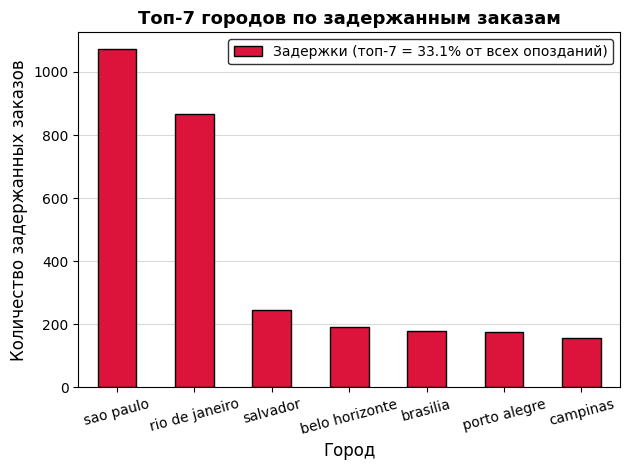

In [75]:
ax = customer_delays.head(7).plot(kind='bar', edgecolor='black', color='#DC143C', alpha=1)

plt.title('Топ-7 городов по задержанным заказам', fontsize=13, fontweight='bold')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество задержанных заказов', fontsize=12)

plt.legend([f'Задержки (топ-7 = {top7_percent}% от всех опозданий)'], edgecolor='black')
plt.grid(axis='y', alpha=.15, color='black')
plt.xticks(rotation=15)

for patch in ax.patches:
    patch.set_zorder(2)

plt.tight_layout()

## ВЫВОД
В ходе анализа выявленно, что присутствует статистическая связь между негативными оценками и опозданием доставки, но опоздания не ключевой фактор влияющий на оценку.
### Рекомендации
- Выяснить причины задержки в топ-3 городах, сравнить их с причинами в топ-7 городах (покрывающих ~30% всех опозданий)
- Устранить логистические проблемы по доставке
- Провести анализ тональностей негативных комментариев, выявить топ-3 причины негодования пользователей




---

## Топ штатов по клиентской базе

In [52]:
top_sellers = df_sellers['seller_state'].value_counts().sort_values(ascending=False).head(10)

In [53]:
print(top_sellers.index, top_sellers.values)

Index(['SP', 'PR', 'MG', 'SC', 'RJ', 'RS', 'GO', 'DF', 'ES', 'BA'], dtype='object', name='seller_state') [1849  349  244  190  171  129   40   30   23   19]


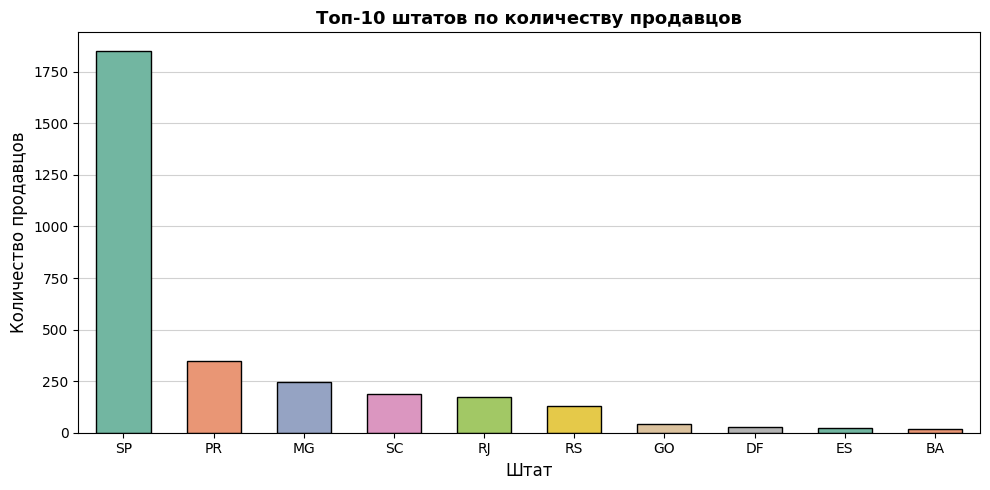

In [54]:
fig = plt.figure(figsize=(10, 5))

plt.grid(axis='y', alpha=.18, color='black', linestyle='-')

ax = sns.barplot(x=top_sellers.index, y=top_sellers.values,
                 hue=top_sellers.index, palette='Set2', width=0.6, edgecolor='black')
plt.xlabel('Штат', fontsize=12)
plt.ylabel('Количество продавцов', fontsize=12)
plt.title('Топ-10 штатов по количеству продавцов', fontsize=13, fontweight='bold')

for patch in ax.patches:
    patch.set_zorder(2)

plt.tight_layout()

In [55]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [56]:
top_customers = df_customers.customer_state.value_counts().sort_values(ascending=False).head(10)

In [57]:
print(top_customers.index, top_customers.values)

Index(['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'DF', 'ES', 'GO'], dtype='object', name='customer_state') [41746 12852 11635  5466  5045  3637  3380  2140  2033  2020]


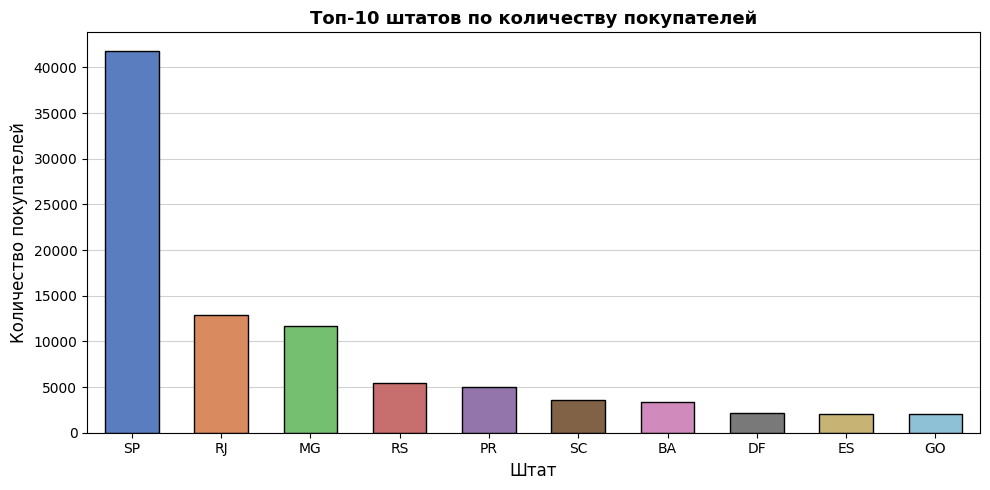

In [58]:
fig = plt.figure(figsize=(10, 5))

plt.grid(axis='y', alpha=.18, color='black', linestyle='-')

ax = sns.barplot(x=top_customers.index, y=top_customers.values,
                 hue=top_customers.index, palette='muted', width=0.6, edgecolor='black')
plt.xlabel('Штат', fontsize=12)
plt.ylabel('Количество покупателей', fontsize=12)
plt.title('Топ-10 штатов по количеству покупателей', fontsize=13, fontweight='bold')

for patch in ax.patches:
    patch.set_zorder(2)

plt.tight_layout()

---

## Анализ метрик LTV (Lifetime Value) и AOV (Average Order Value)

In [59]:
df['order_total'] = df['price'] + df['freight_value']

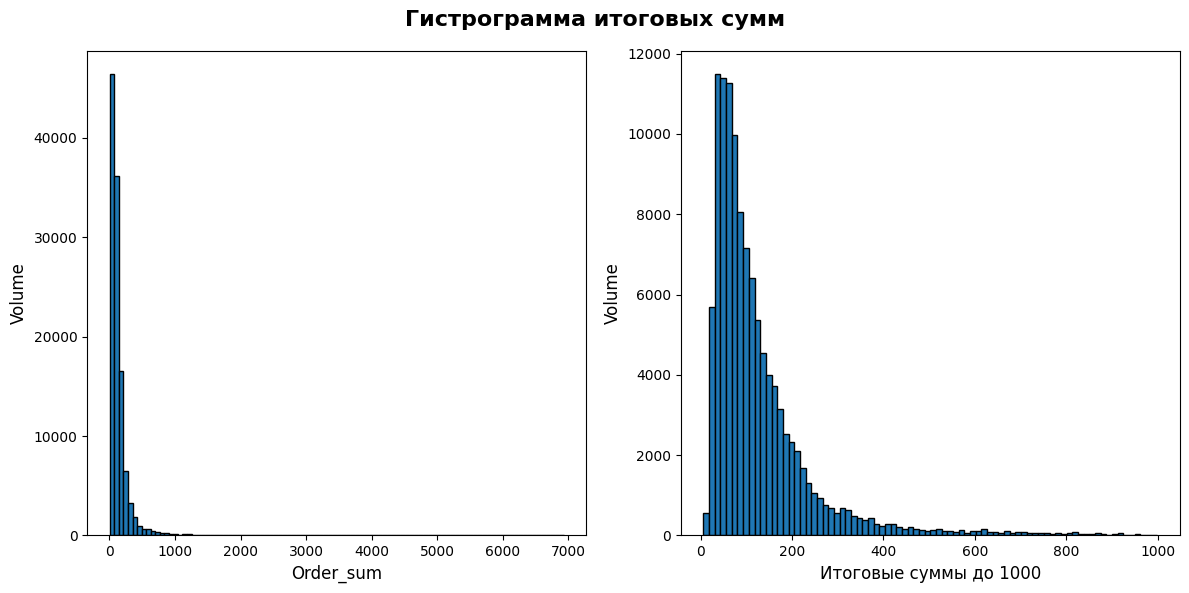

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ax1 = axes[0]
ax2 = axes[1]

ax1.hist(df['order_total'], bins=100, edgecolor='black')
ax1.set_ylabel('Volume', fontsize=12)
ax1.set_xlabel('Order_sum', fontsize=12)

fig.suptitle('Гистрограмма итоговых сумм', fontsize=16, fontweight='bold')

ax2.hist(df['order_total'][df['order_total'] < 1000], bins=80, edgecolor='black')
ax2.set_ylabel('Volume', fontsize=12)
ax2.set_xlabel('Итоговые суммы до 1000', fontsize=12)

plt.tight_layout()
plt.show()

### AOV

In [61]:
orders_sum = df.groupby('order_id')['order_total'].sum()

In [62]:
Q1 = orders_sum.quantile(.05)
Q3 = orders_sum.quantile(.95)

In [63]:
print(f'Медиана: {orders_sum.median()}')
print(f'AOV, с удалёнными 5% хвостами: {orders_sum[(orders_sum > Q1) & (orders_sum < Q3)].mean():.2f}')
print(f'AOV: {orders_sum.mean():.2f}')
print(f'AOV с данными < 1000: {orders_sum[orders_sum < 1000].mean():.2f}')

Медиана: 107.78
AOV, с удалёнными 5% хвостами: 133.59
AOV: 168.51
AOV с данными < 1000: 148.10


### Далее посчитаем Revenue LTV и затем сформулируем вывод

In [64]:
customers_total = df.groupby(['customer_id']).agg(
    total_revenue_per_customer = ('order_total', 'sum'),
    orders_count_per_customer = ('order_id', 'count'),
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max')
).reset_index()

In [65]:
customers_total.sort_values('orders_count_per_customer', ascending=False)

,customer_id,total_revenue_per_customer,orders_count_per_customer,first_purchase,last_purchase
14798,270c23a11d024a44c896d1894b261a83,3387.72,63,2017-08-08 20:26:31,2017-08-08 20:26:31
7380,13aa59158da63ba0e93ec6ac2c07aacb,3909.06,38,2017-09-23 14:56:45,2017-09-23 14:56:45
58465,9af2372a1e49340278e7c1ef8d749f34,13281.71,29,2017-04-20 12:45:34,2017-04-20 12:45:34
55315,92cd3ec6e2d643d4ebd0e3d6238f69e2,1629.68,26,2017-06-07 12:05:10,2017-06-07 12:05:10
37515,63b964e79dee32a3587651701a2b8dbf,10553.28,24,2018-02-14 16:34:27,2018-02-14 16:34:27
...,...,...,...,...,...
96515,fff25ab9d3c9ba6ad8119576f285a3d9,220.71,1,2017-05-04 11:08:52,2017-05-04 11:08:52
96516,fff39f01a81d96b066b1893ad395a98b,17.29,1,2018-07-01 11:49:01,2018-07-01 11:49:01
7225,134a1bdf2deb906cf9e47363d42a8ff5,129.00,1,2017-05-18 12:01:53,2017-05-18 12:01:53
96518,fff415b4c72e09483a25c15108c65d31,84.57,1,2017-11-24 14:23:07,2017-11-24 14:23:07


In [66]:
print(f'Revenue LTV median: {customers_total.total_revenue_per_customer.median()}')
print(f'Revenue LTV mean: {customers_total.total_revenue_per_customer.mean()}')

Revenue LTV median: 107.78
Revenue LTV mean: 168.51369292284744


In [67]:
# процент клиентов с 1 заказом
round(customers_total[customers_total['orders_count_per_customer'] == 1].shape[0]/customers_total.shape[0]*100, 2)

86.96

## Вывод
В связи с высоким процентом выбросов, которые сильно искажают средние значения, для оценки «типичного» клиента мы берем медианные значения: LTV = AOV = 107.78.
Такое равенство напрямую обусловлено тем, что ~87% клиентов совершают только 1 покупку и больше не возвращаются на платформу.
Рекомендуется интегрировать механизмы удержания клиентов по типу системы "лояльности" и push-уведомлений о скидках, акциях.

---

## RFM-анализ

In [78]:
# Есть переменная max_date в date формате, пересчитаем её в timestamp
max_date = pd.to_datetime(max(df['order_purchase_timestamp']))

In [114]:
df['day_diff'] = (max_date-df['order_purchase_timestamp']).dt.days

In [115]:
recency = df.groupby('customer_unique_id')['day_diff'].min().reset_index()
recency.columns = ['id', 'recency']

In [116]:
print(df['day_diff'].describe())

count    115633.000000
mean        245.522541
std         153.514820
min           0.000000
25%         121.000000
50%         227.000000
75%         355.000000
max         728.000000
Name: day_diff, dtype: float64


In [117]:
frequency = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequency.columns = ['id', 'frequency']

In [118]:
monetary = df.groupby('customer_unique_id')['order_total'].sum().reset_index()
monetary.columns = ['id', 'monetary']
print(f"Максимальное значение: {monetary['monetary'].max()}")
print(f"Минимальное значение: {monetary['monetary'].min()}")

Максимальное значение: 13664.08
Минимальное значение: 10.07


In [119]:
print(recency.shape, frequency.shape, monetary.shape)

(93415, 2) (93415, 2) (93415, 2)


<Axes: xlabel='monetary', ylabel='Count'>

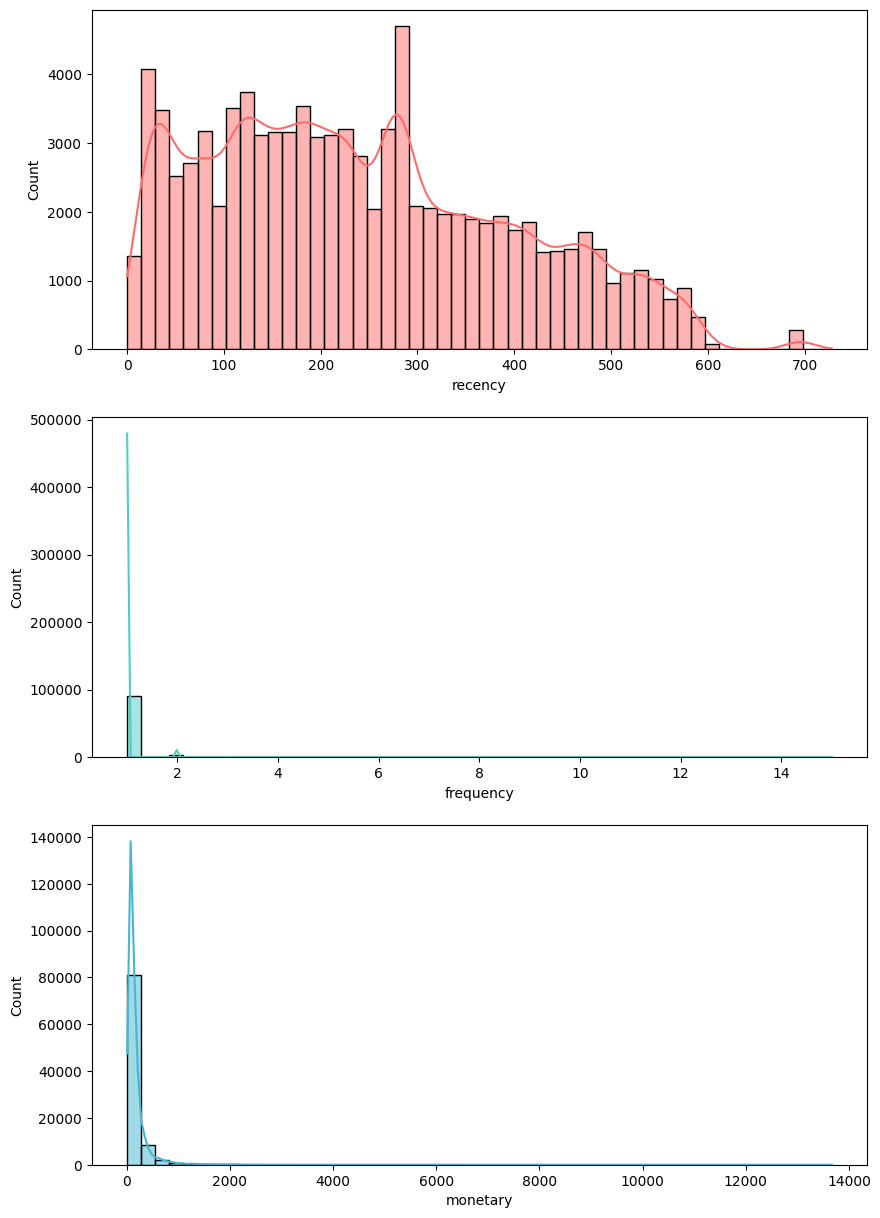

In [126]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]

sns.histplot(recency['recency'], bins=50, kde=True, ax=ax1, color='#FF6B6B')

sns.histplot(frequency['frequency'], bins=50,  kde=True, ax=ax2, color='#4ECDC4')

sns.histplot(monetary['monetary'], bins=50,  kde=True, ax=ax3, color='#45B7D1')